In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import blurtool

import torch
from PIL import Image

import matplotlib.pyplot as plt
import torchvision
import math
import random

# Nonstationary blur modeling using robust eigenkernels

Abstract: 

### Example 0
figure showing LSV convolution, approximate LSV filter and PCA eigenkernel forward method.

In [2]:
# test approx=False in nonstationary blur with a nondecomposed lattice (parallel forward)

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
img_shape=test_image.shape
print('img_shape=',img_shape)

# define lattice
kernel_shape=(25,25)
lattice_pars={'ax':0.1,'ay':0.1,'bx':0.3,'by':0.2,'gamma_x':2,'gamma_y':2}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)
print('sampled_shape=',sampled_shape)
r=20
pars_pca={'r':r}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)

# lsvc blur
rgblur_lsvc=blurtool.NonstationaryBlur(lat,approx=False)
blurred_test_image_lsvc=rgblur_lsvc.forward(test_image,n_pool=4)

# approx filter blur
rgblur=blurtool.NonstationaryBlur(lat)
blurred_test_image=rgblur.forward(test_image,n_pool=4)

# pca lat blur 
pca_blur=blurtool.NonstationaryBlur(pca_lat)
blurred_test_image_pca=pca_blur.forward(test_image)

# # results
fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image_lsvc,cmap='gray')
ax[2].axis('off')
ax[2].imshow(blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(blurred_test_image_pca,cmap='gray')
plt.show()

print('-------------------------------------------------------')
print('forward_timer_lsvc=',rgblur_lsvc.forward_timer)
print('forward_timer_approxfilter=',rgblur.forward_timer)
print('forward_timer_pca=',pca_blur.forward_timer)
print('-------------------------------------------------------')
print('PSNR(blurred_lsvc,blurred_approxfilter)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image))
print('PSNR(blurred_approxfilter,blurred_pca)=',blurtool.psnr(blurred_test_image,blurred_test_image_pca))
print('PSNR(blurred_lsvc,blurred_pca)=',blurtool.psnr(blurred_test_image_lsvc,blurred_test_image_pca))
print('-------------------------------------------------------')
print('SSIM(blurred_lsvc,blurred_approxfilter)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image))
print('SSIM(blurred_approxfilter,blurred_pca)=',blurtool.ssim(blurred_test_image,blurred_test_image_pca))
print('SSIM(blurred_lsvc,blurred_pca)=',blurtool.ssim(blurred_test_image_lsvc,blurred_test_image_pca))

# save images
plt.imshow(test_image,cmap='gray')
plt.axis('off')
plt.savefig('ex0_x.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_lsvc,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_lvsc.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_approxfilter.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

plt.imshow(blurred_test_image_pca,cmap='gray')
plt.axis('off')
plt.savefig('ex0_y_pca.eps',dpi=300, bbox_inches='tight',pad_inches=0)
plt.show()

img_shape= torch.Size([256, 256])
kernel_shape= (25, 25)
sampled_shape= (8, 8)


/home/mauro/miniconda3/envs/blurtool/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
Process SpawnPoolWorker-1:
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-2:
Traceback (most recent call last):
  File "/home/mauro/miniconda3/envs/blurtool/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
   

## Numerical experiments

### Example 1 (salt and pepper corrupted PSF)

img_shape= torch.Size([256, 256])
kernel_shape= (27, 27)
mu= tensor(82.9719) . lamb= 0.06 . rank= 0


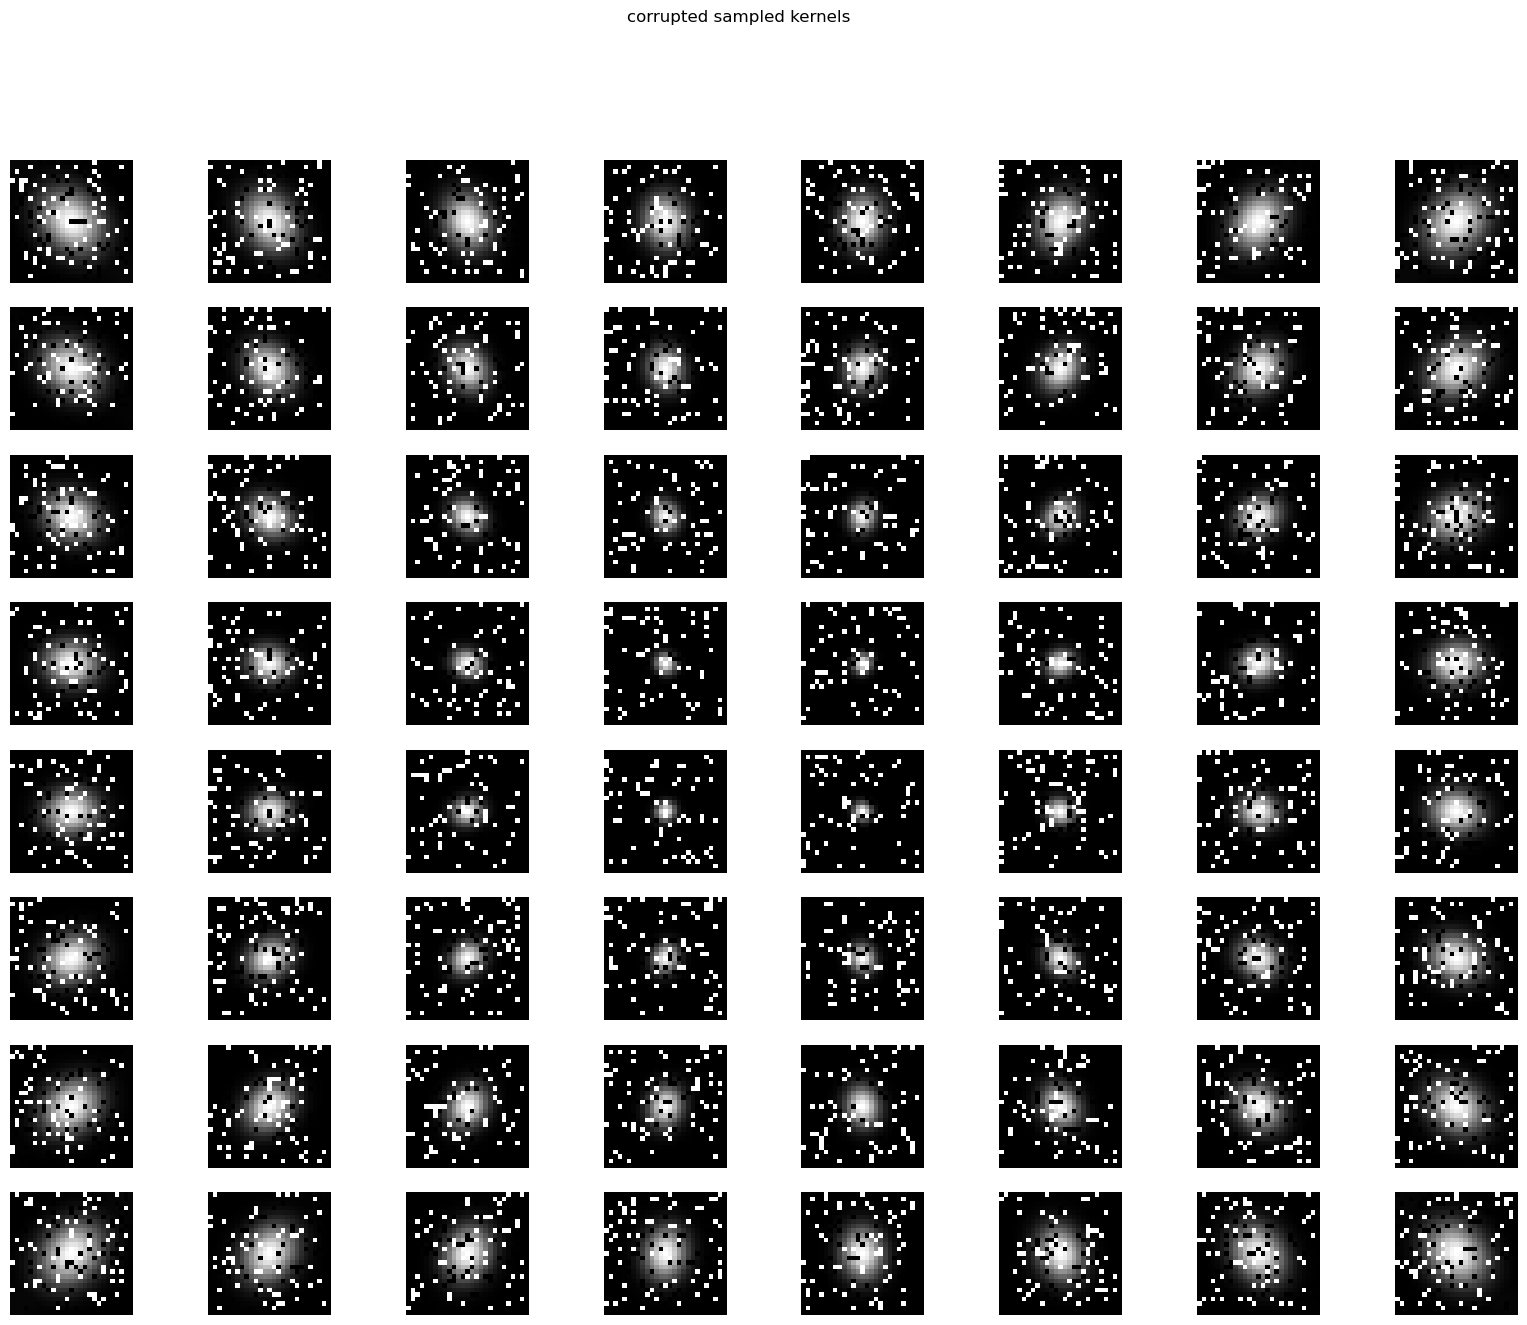

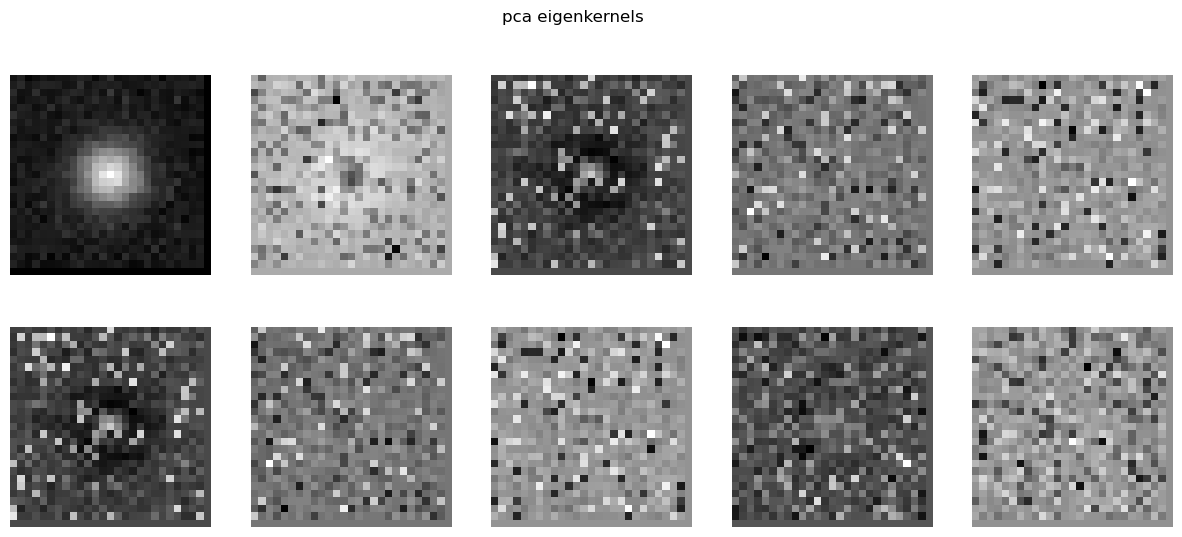

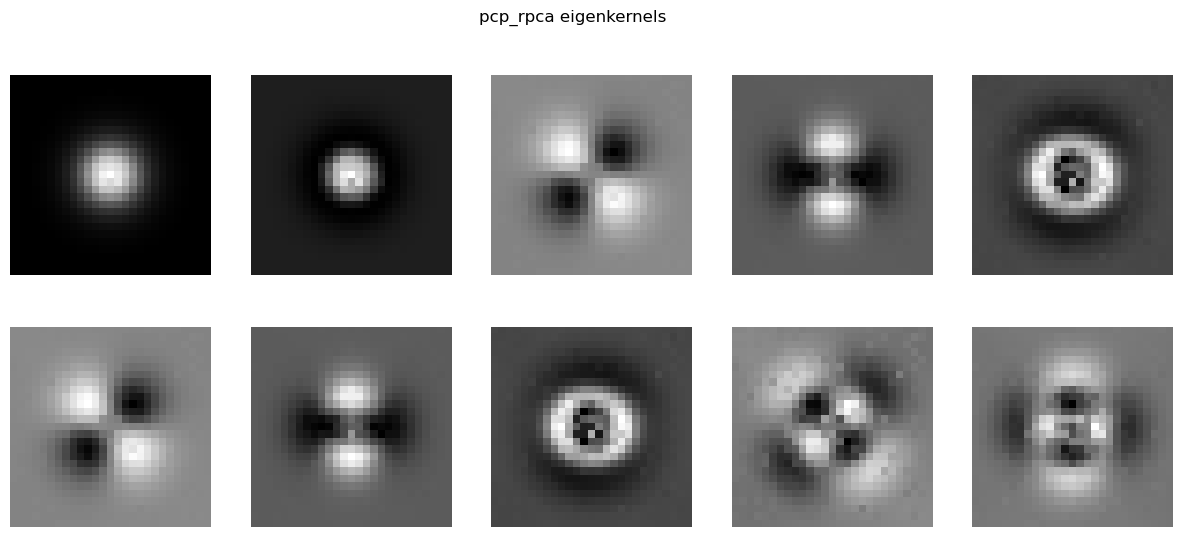

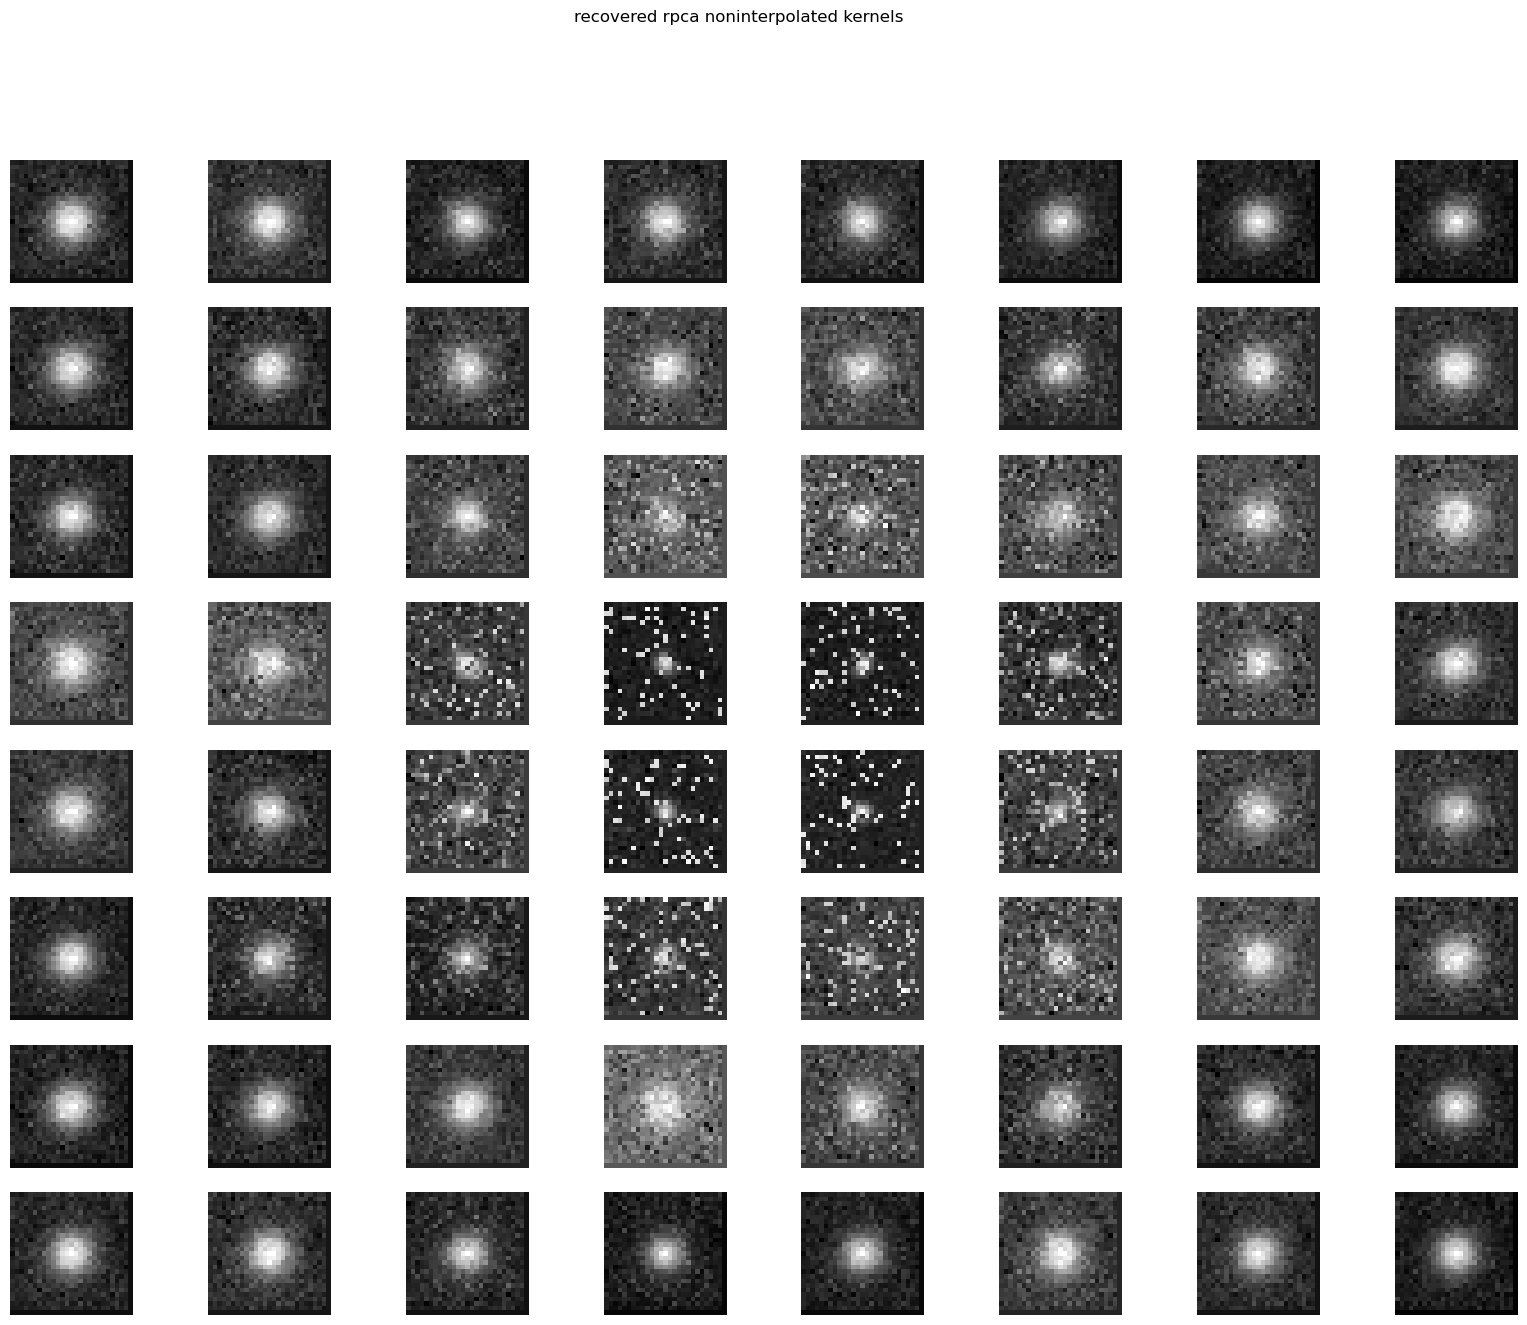

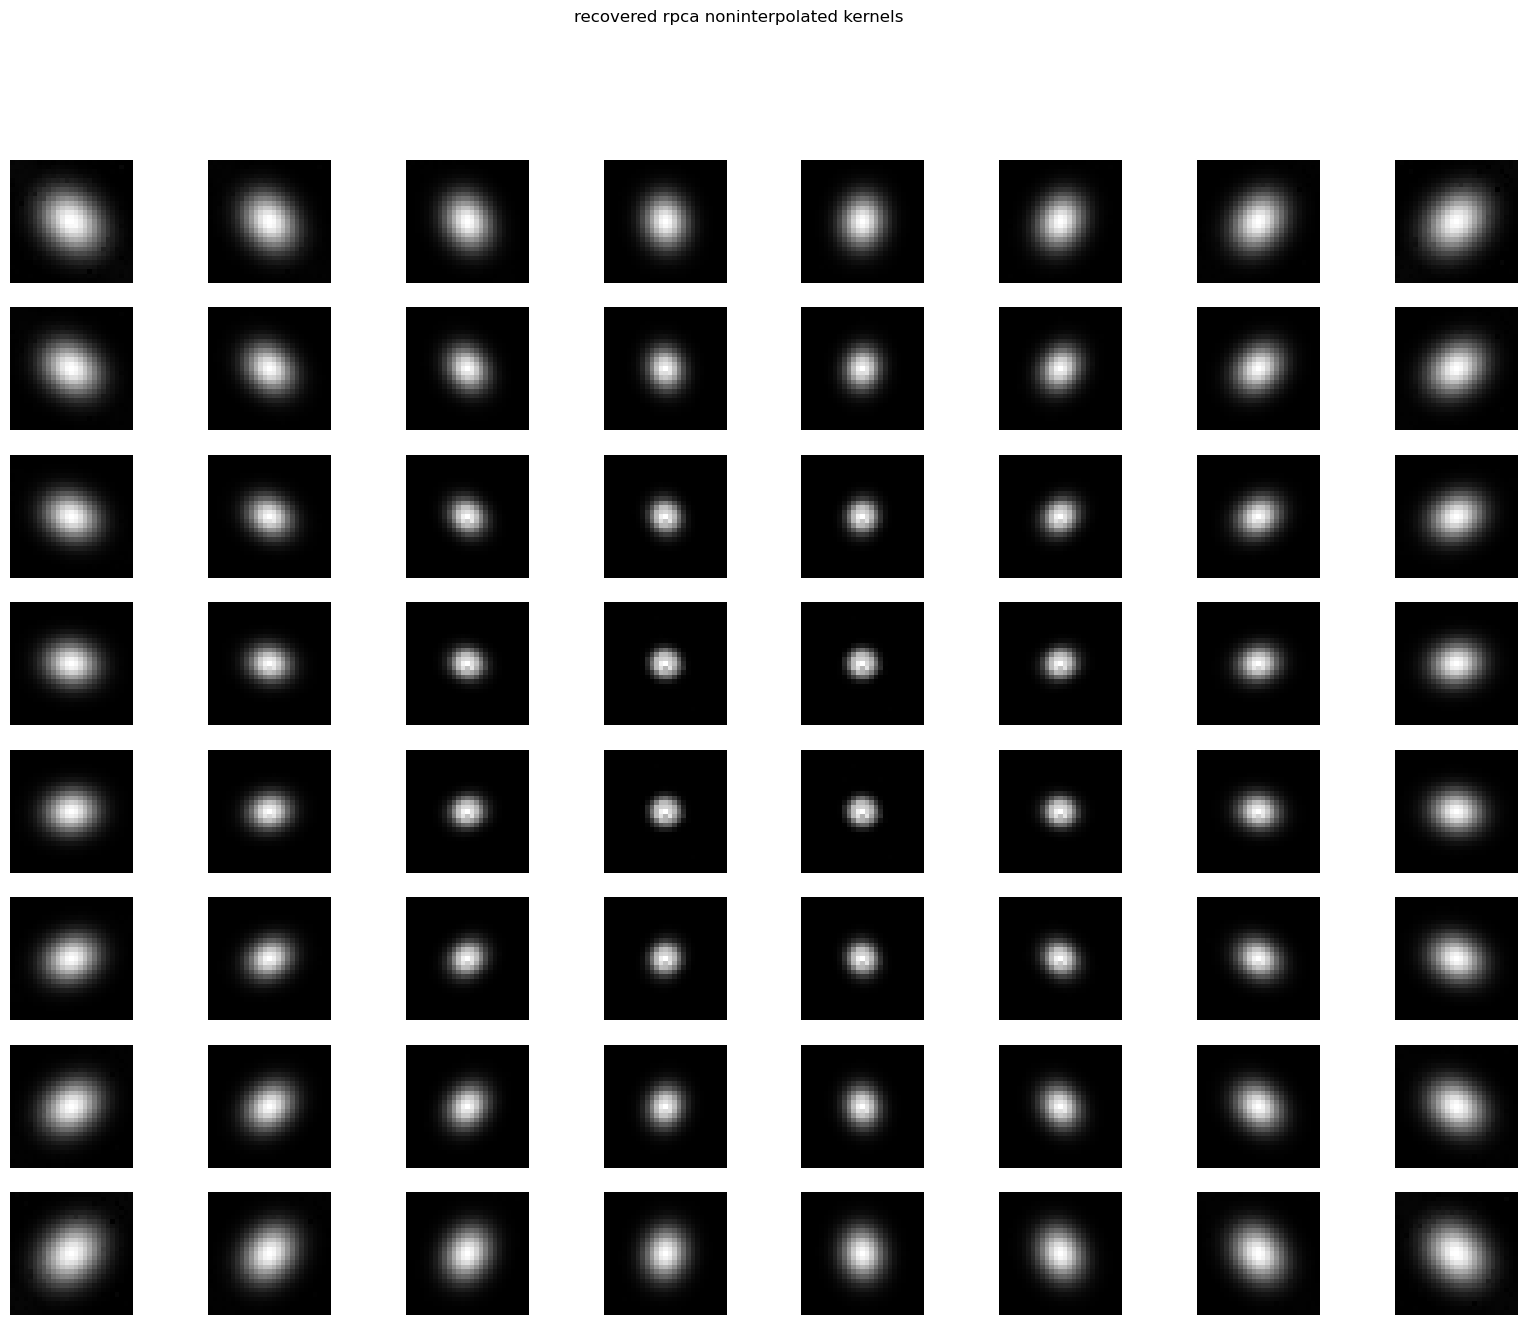

finished row  0
finished row  1
finished row  2
finished row  3
finished row  4
finished row  5
finished row  6
finished row  7
finished row  8
finished row  9
finished row  10
finished row  11
finished row  12
finished row  13
finished row  14
finished row  15
finished row  16
finished row  17
finished row  18
finished row  19
finished row  20
finished row  21
finished row  22
finished row  23
finished row  24
finished row  25
finished row  26
finished row  27
finished row  28
finished row  29
finished row  30
finished row  31
finished row  32
finished row  33
finished row  34
finished row  35
finished row  36
finished row  37
finished row  38
finished row  39
finished row  40
finished row  41
finished row  42
finished row  43
finished row  44
finished row  45
finished row  46
finished row  47
finished row  48
finished row  49
finished row  50
finished row  51
finished row  52
finished row  53
finished row  54
finished row  55
finished row  56
finished row  57
finished row  58
finishe

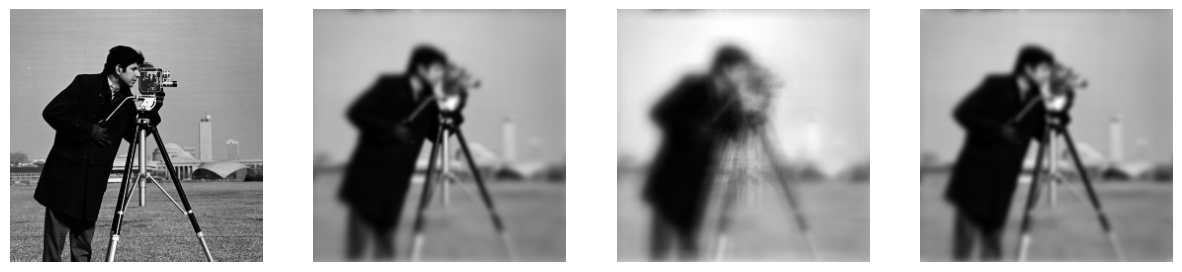

In [102]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(27,27)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.2) # 0.1
    
# decompose sampled lattice
r=10
pars_pca={'r':r}
pars_rpca={'lamb':0.06,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # lamb=0.16
# pars_rpca={'r':r,'debug':False}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)


# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])(),cmap='gray')
plt.show()

# plot pca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot pcp_rpca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pcp_rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot reconsctructed pca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

## blur a test image 

# define blurs and apply
blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)

blurred_test_image=blur.forward(test_image,n_pool=1,debug=True)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image,cmap='gray')

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))
print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image))

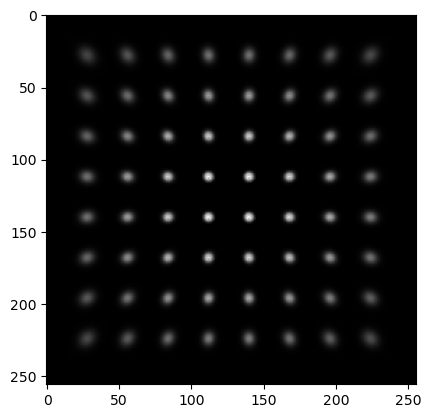

In [103]:
plt.imshow(rpca_lat.grid((8,8),blur=True),cmap='gray')

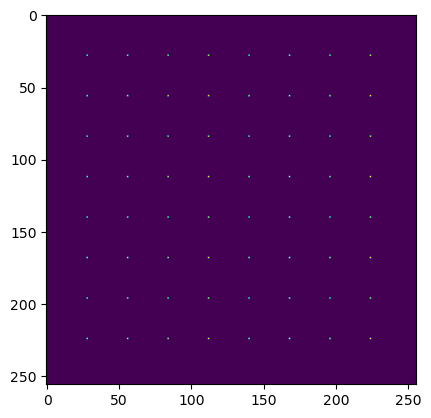

In [104]:
plt.imshow(pca_lat.grid((8,8)))

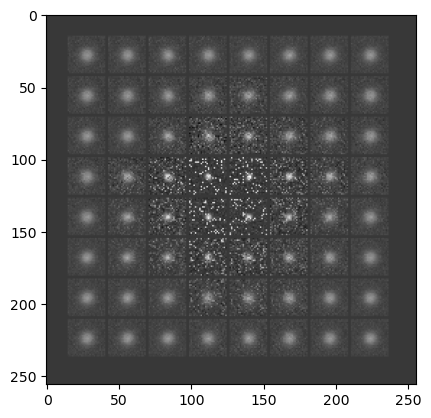

In [105]:
plt.imshow(pca_lat.grid((8,8),blur=True),cmap='gray')

In [106]:
plt.imshow(lat.grid((8,8),blur=True),cmap='gray')


KeyboardInterrupt



img_shape= torch.Size([128, 128])
kernel_shape= (17, 17)
mu= tensor(41.4875) . lamb= 0.21 . rank= 0


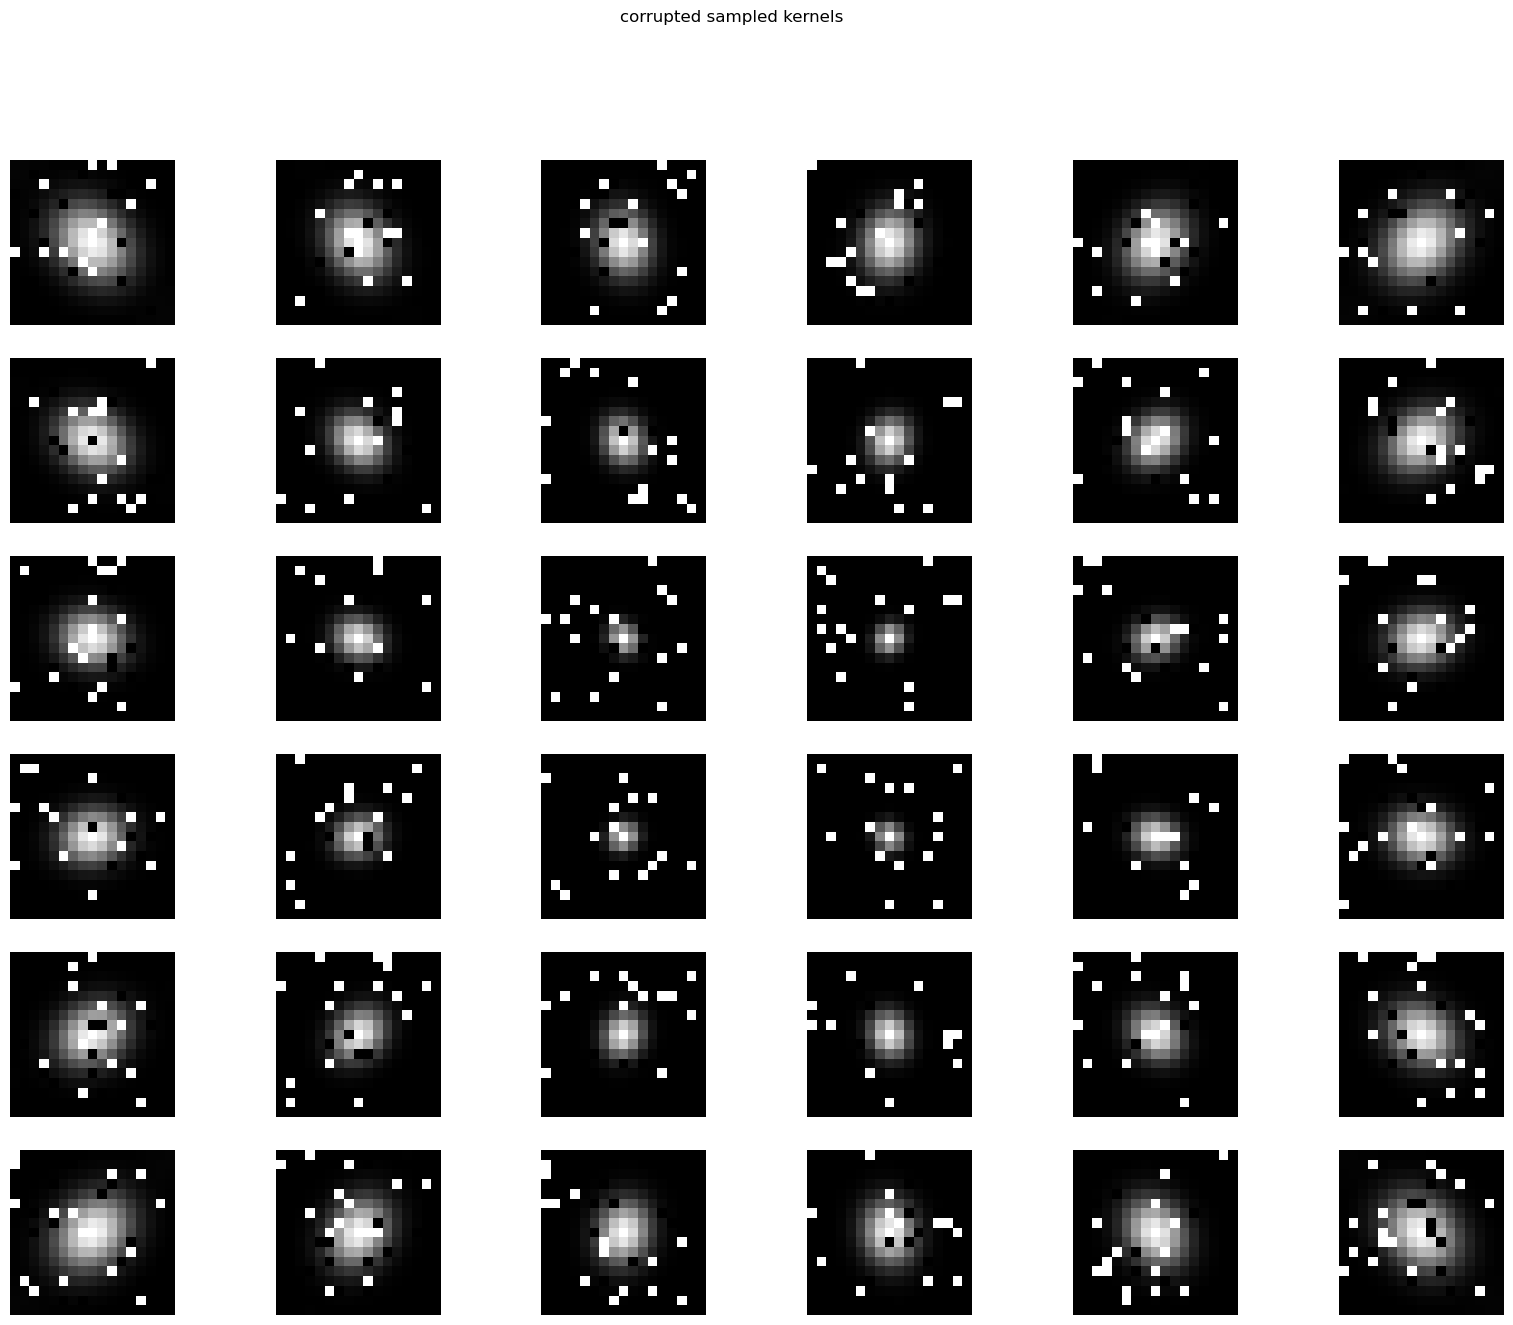

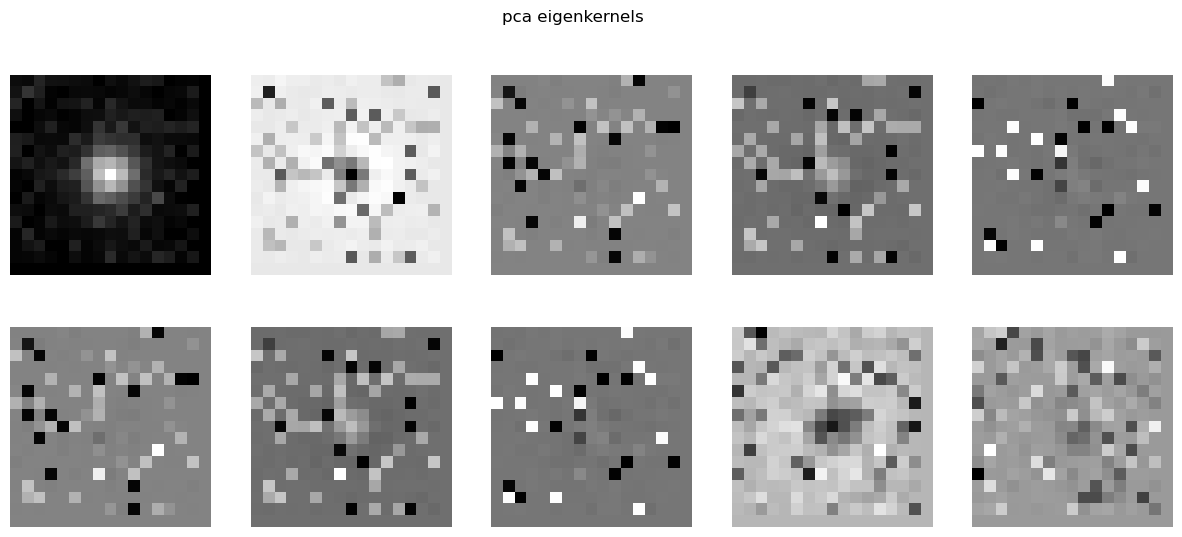

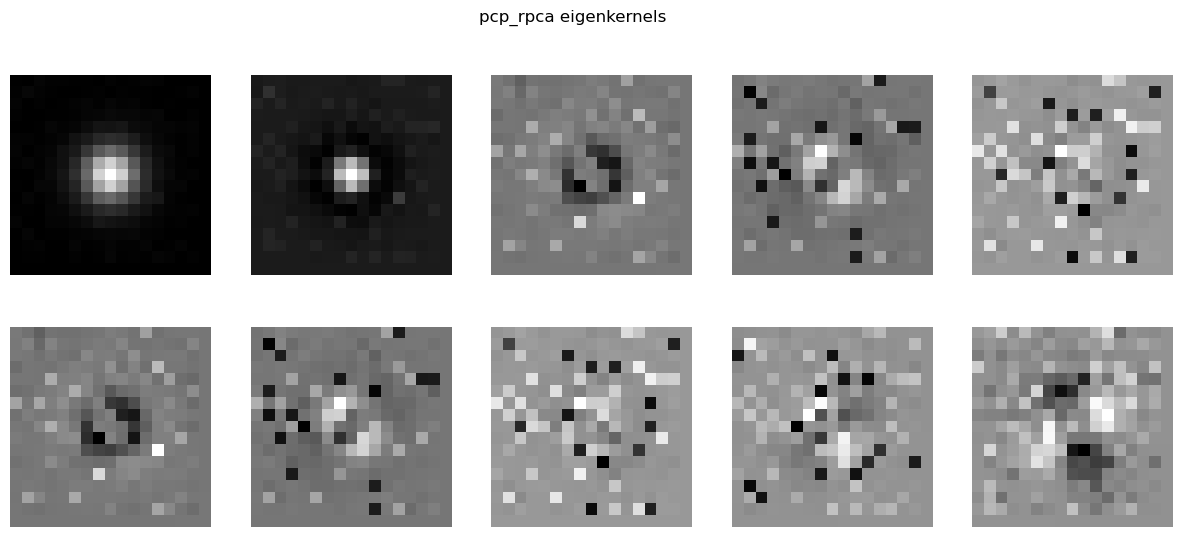

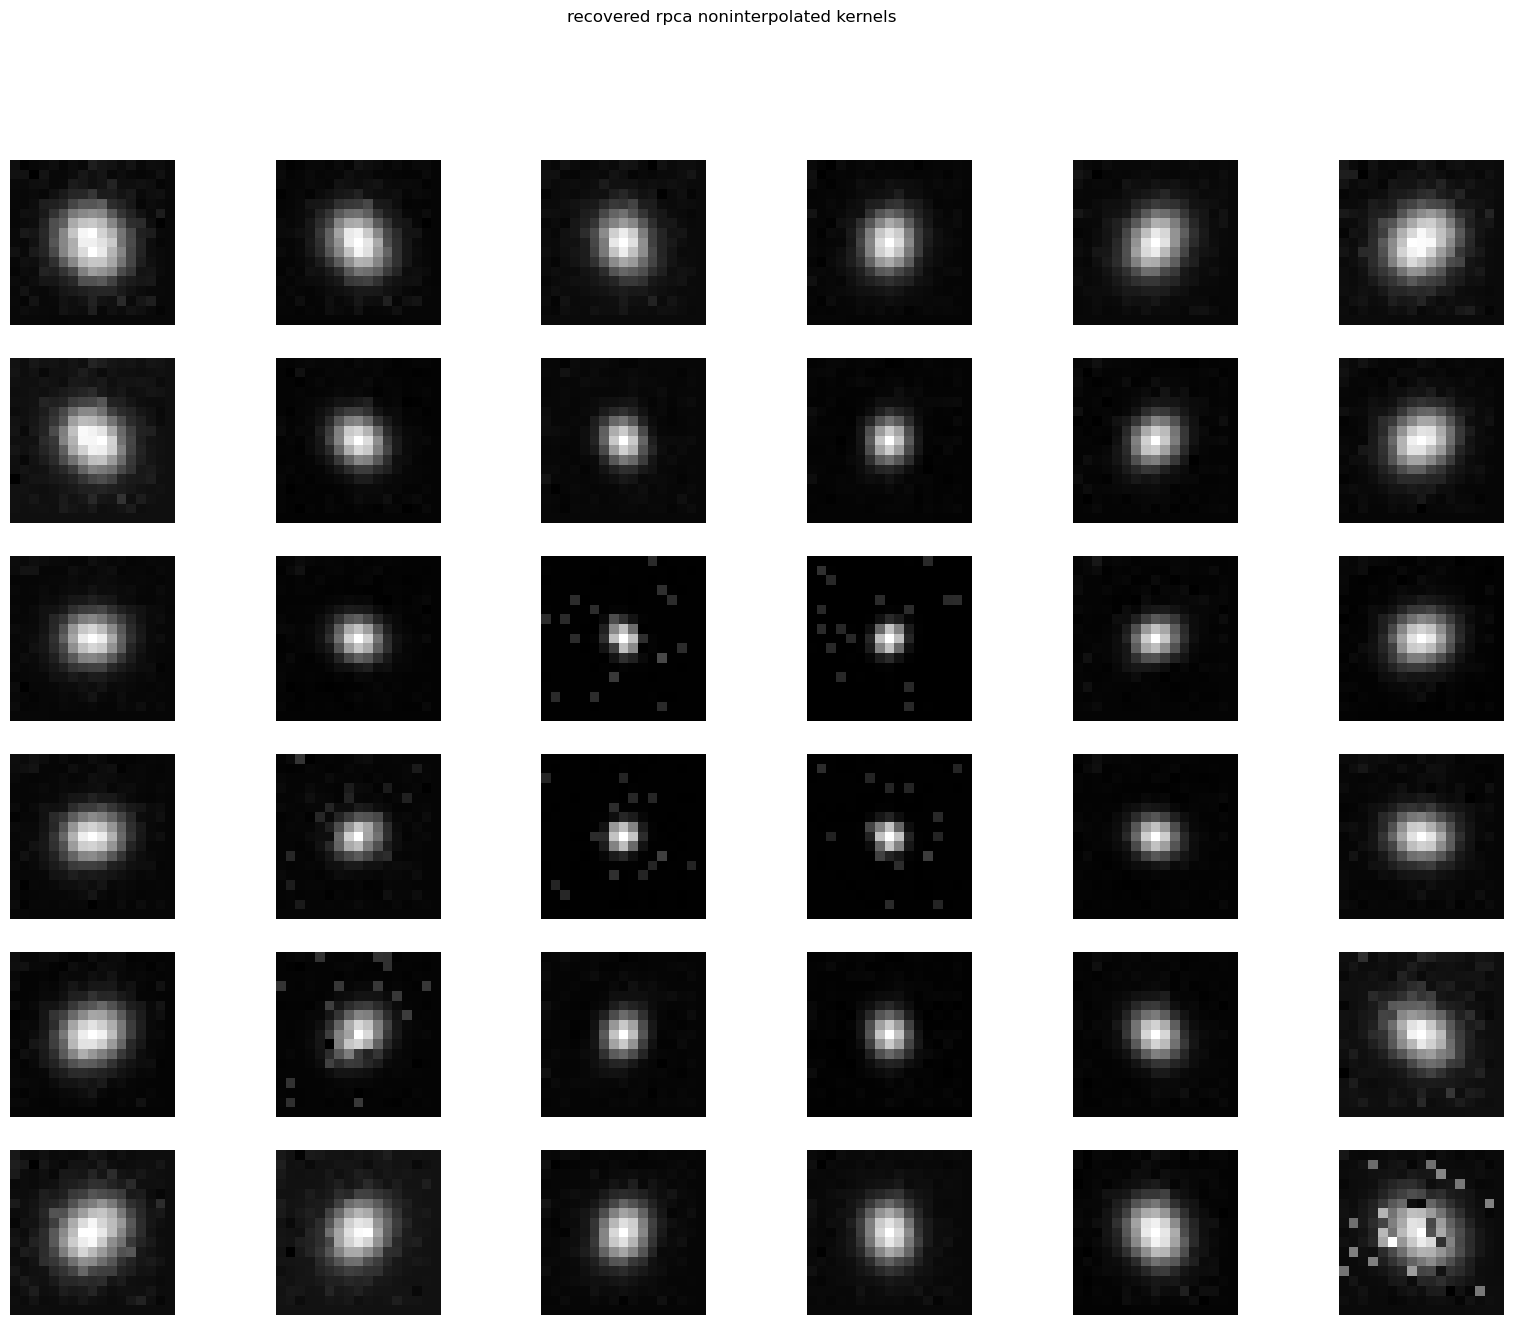

blur.forward_timer= 20.51540661099716
pca_blur.forward_timer= 0.023068836017046124
rpca_blur.forward_timer= 0.02188879798632115
PSNR(blurred,pca_blurred)= tensor(13.7711, dtype=torch.float64)
PSNR(blurred,rpca_blurred)= tensor(31.8388, dtype=torch.float64)
SSIM(blurred,pca_blurred)= tensor(0.7492, dtype=torch.float64)
SSIM(blurred,rpca_blurred)= tensor(0.9874, dtype=torch.float64)


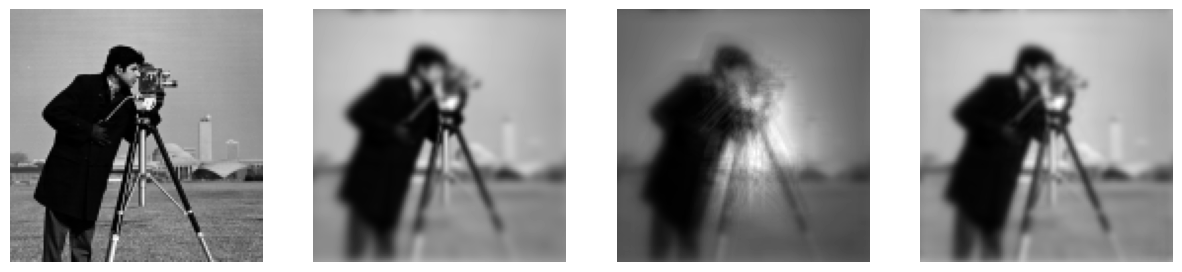

In [49]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(128))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(17,17)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(6,6)
sampled_lat=lat.sample(sampled_shape)

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.1)
    
# decompose sampled lattice
r=10
pars_pca={'r':r}
pars_rpca={'lamb':0.21,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # lamb=0.15
# pars_rpca={'r':r,'debug':False}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)


# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])(),cmap='gray')
plt.show()

# plot pca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot pcp_rpca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pcp_rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

## blur a test image 

# define blurs and apply
# blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)


# blurred_test_image=blur.forward(test_image,n_pool=4,debug=False)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image,cmap='gray')

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))
print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image))

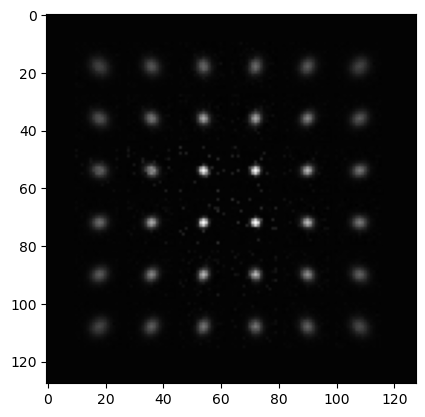

In [47]:
plt.imshow(rpca_lat.grid((6,6),blur=True),cmap='gray')

# plt.imshow(rpca_blur.forward(pca_lat.grid((8,8))),cmap='gray')

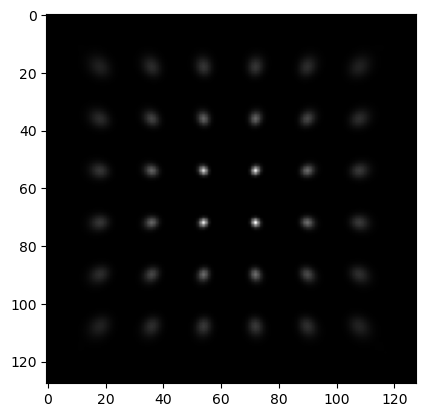

In [48]:
plt.imshow(lat.grid((6,6),blur=True),cmap='gray')

img_shape= torch.Size([256, 256])
kernel_shape= (23, 23)
mu= tensor(78.2840) . lamb= 0.15 . rank= 0


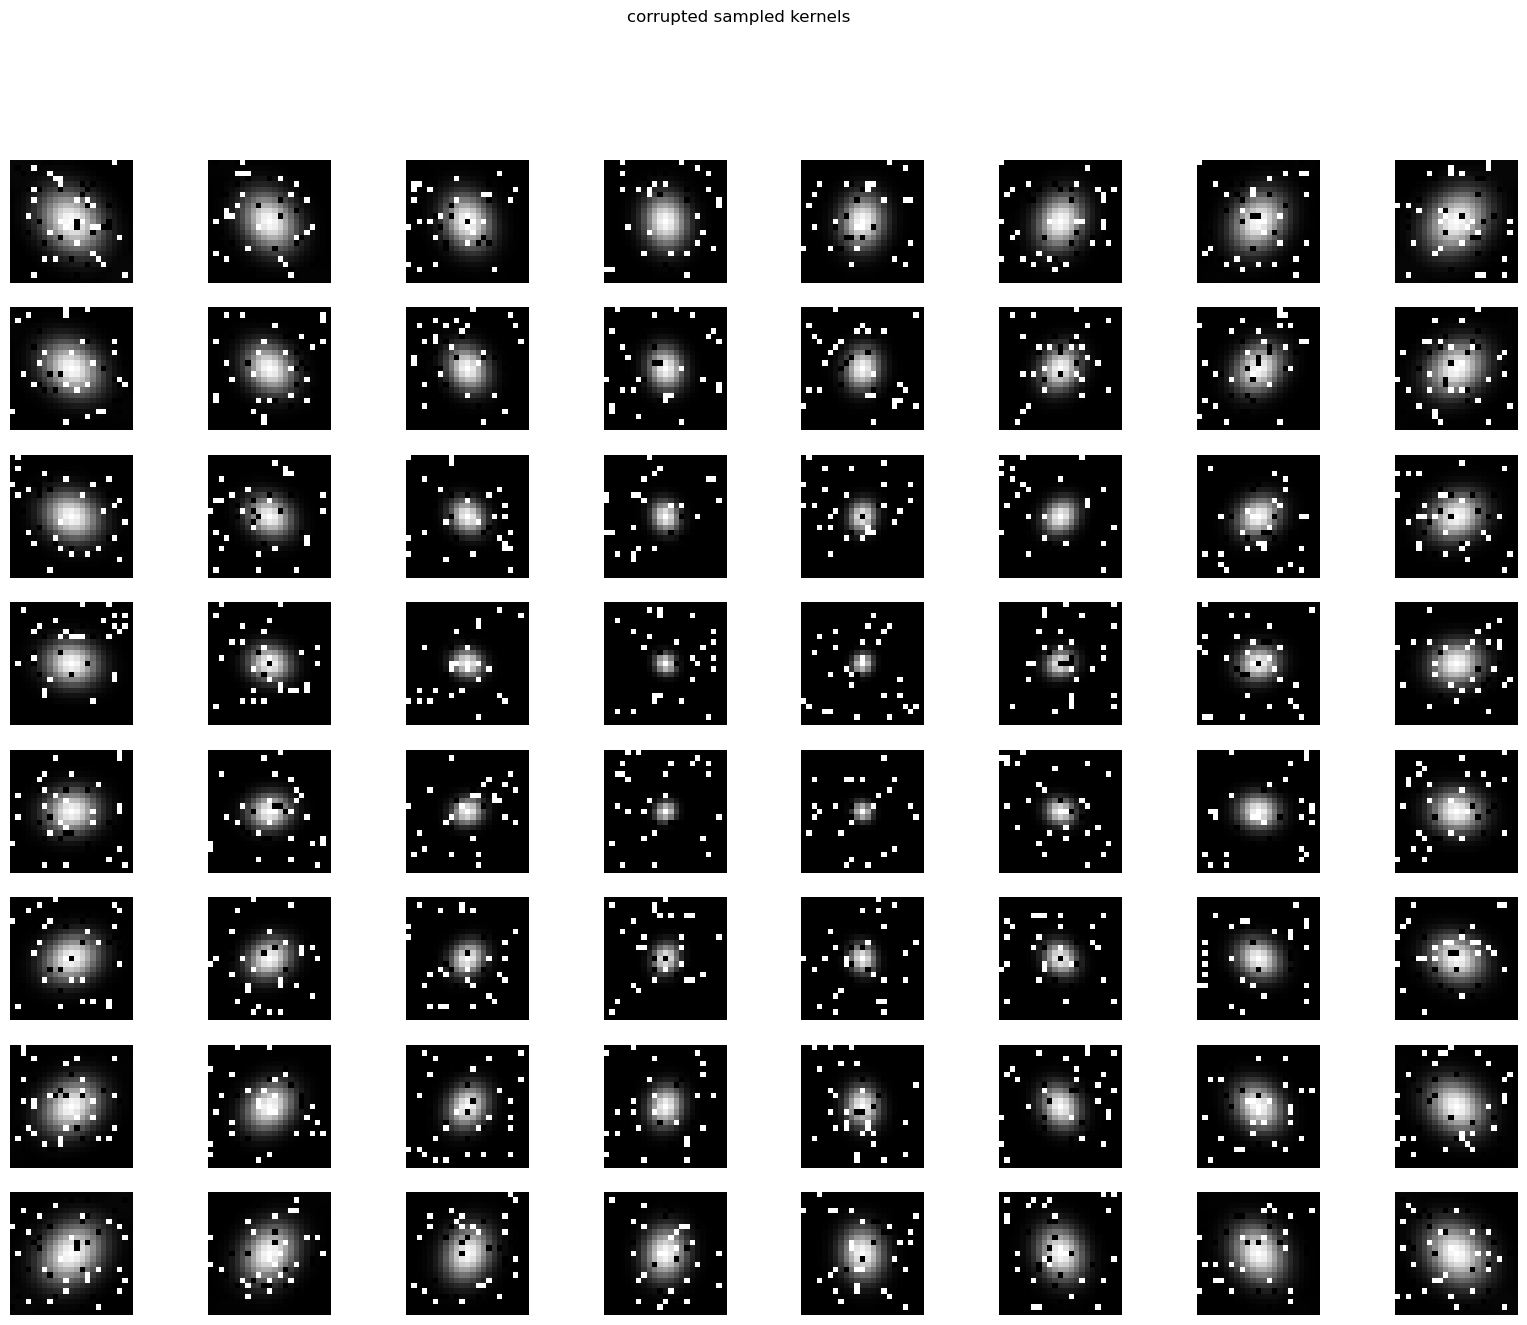

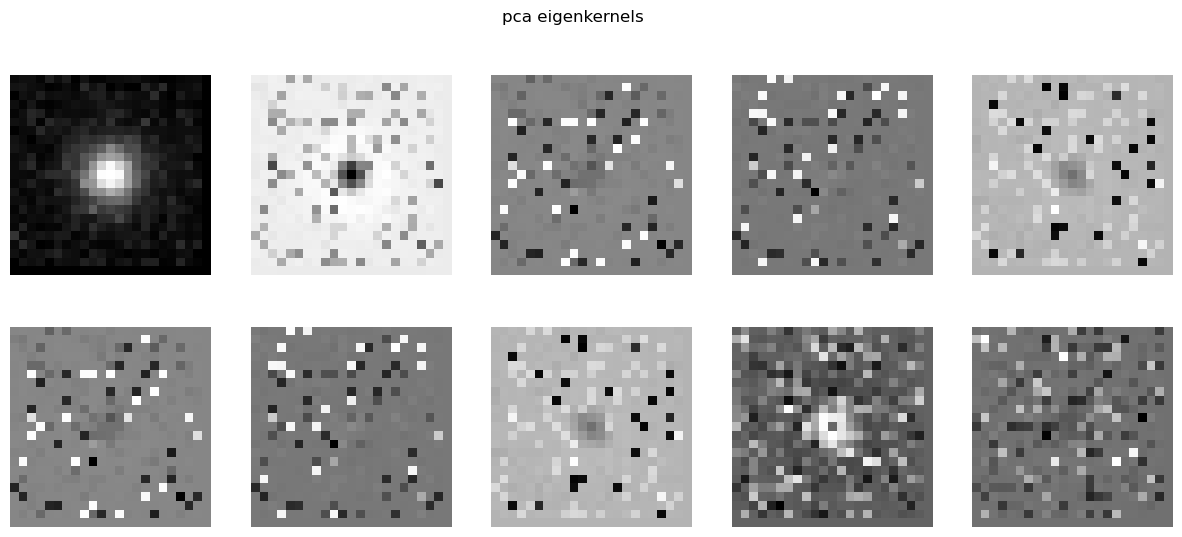

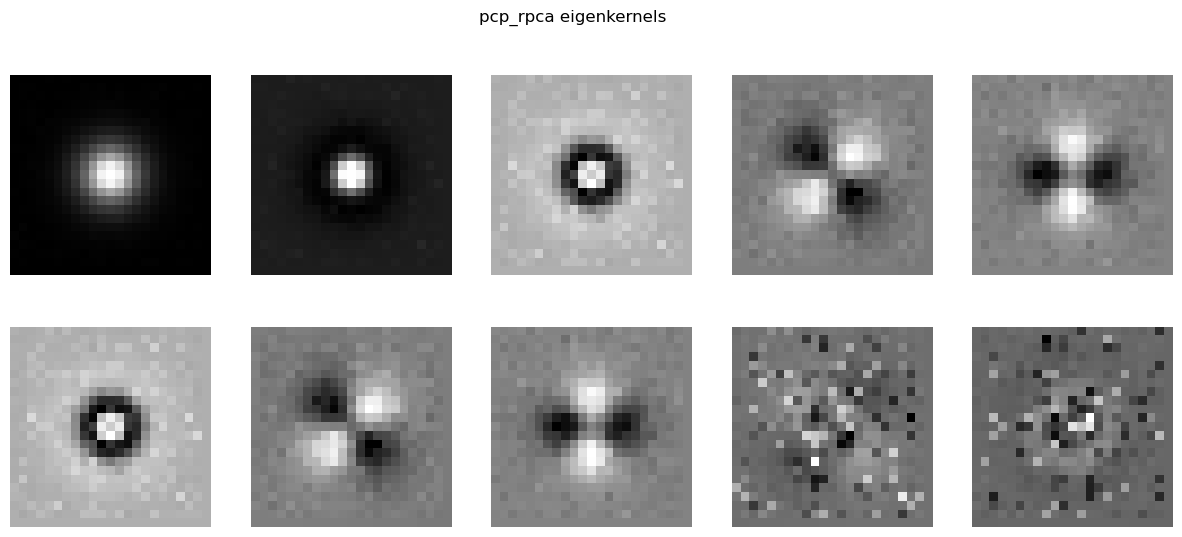

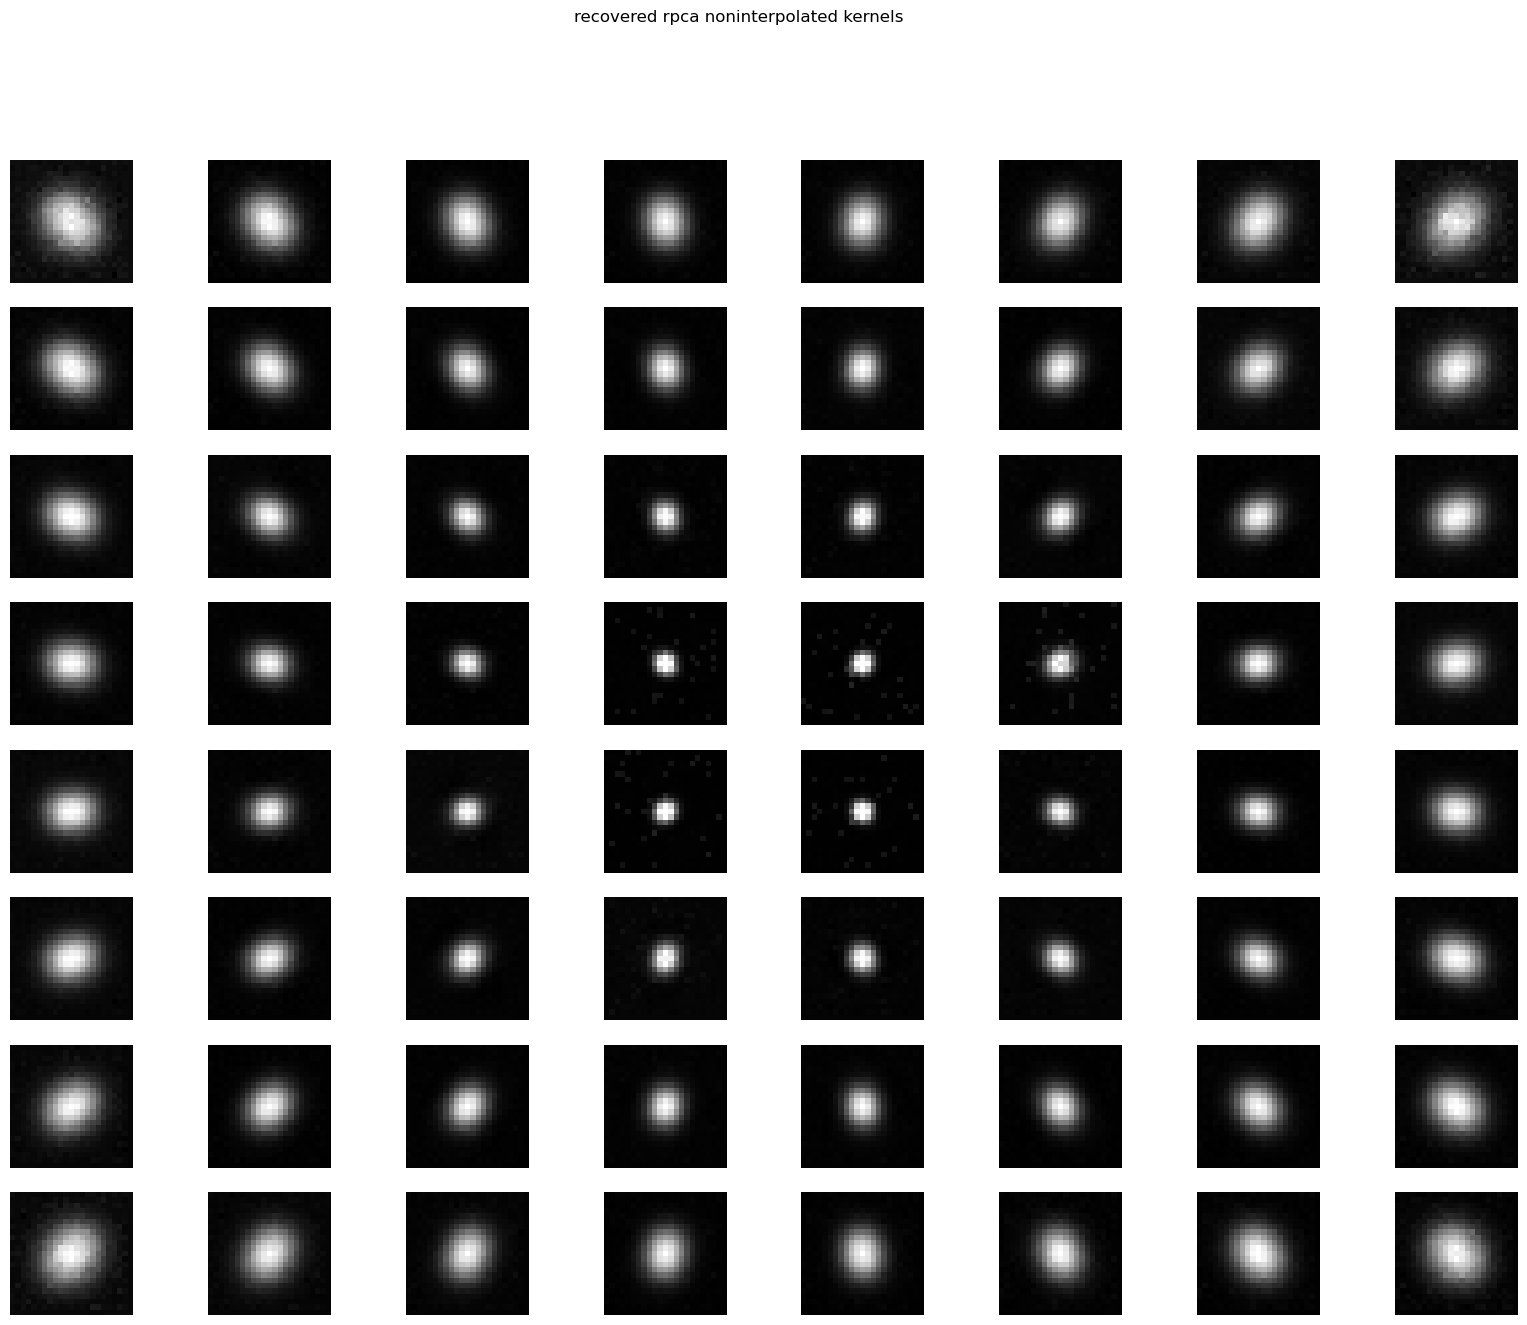

Exception in thread Thread-32 (_handle_results):
Traceback (most recent call last):
  File "/home/mauro/miniconda3/envs/decompba/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/mauro/miniconda3/envs/decompba/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/home/mauro/miniconda3/envs/decompba/lib/python3.10/multiprocessing/pool.py", line 579, in _handle_results
    task = get()
  File "/home/mauro/miniconda3/envs/decompba/lib/python3.10/multiprocessing/connection.py", line 251, in recv
    return _ForkingPickler.loads(buf.getbuffer())
  File "/home/mauro/miniconda3/envs/decompba/lib/python3.10/site-packages/torch/multiprocessing/reductions.py", line 322, in rebuild_storage_filename
    storage = torch.UntypedStorage._new_shared_filename_cpu(manager, handle, size)
RuntimeError: unable to mmap 8528 bytes from file </torch_29305_2615028215_13743>: Cannot allocate memory (12)
Process SpawnPoolWork

In [50]:
# blurring a test image with a lattice of kernels versus the sampled-decomposed version of the same lattice

# resizer
resize = torchvision.transforms.Resize(size=(256))

# open test image
test_image=Image.open('../../data/cameraman.tif').convert('L')
test_image=torchvision.transforms.ToTensor()(test_image).squeeze()
test_image=resize(test_image.unsqueeze(0)).squeeze()
test_image=blurtool.normalize_minmax(test_image)
img_shape=test_image.shape
print('img_shape=',img_shape)


# define lattice
kernel_shape=(23,23)
lattice_pars={'ax':0.07,'ay':0.07,'bx':0.4,'by':0.3,'gamma_x':1,'gamma_y':1}
lat=blurtool.RotGaussian(img_shape,kernel_shape,lattice_pars)
print('kernel_shape=',kernel_shape)

# sample original lattice
sampled_shape=(8,8)
sampled_lat=lat.sample(sampled_shape)

# corrupt sampled kernels with salt and pepper noise
for key in sampled_lat.kernels:
    sampled_lat.kernels[key].psf_data=blurtool.spnoise(sampled_lat.kernels[key].psf_data,amount=0.1)
    
# decompose sampled lattice
r=10
pars_pca={'r':r}
pars_rpca={'lamb':0.15,'r':r,'tol':1e-20,'max_iter':500,'debug':False} # lamb=0.15
# pars_rpca={'r':r,'debug':False}
pca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pca',decompose_pars=pars_pca)
rpca_lat=blurtool.DecomposeLattice(sampled_lat,img_shape,mode='pcp_rpca',decompose_pars=pars_rpca)


# plot corrupted sampled kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('corrupted sampled kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(sampled_lat.kernel([i,j])(),cmap='gray')
plt.show()

# plot pca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(pca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot pcp_rpca kernels
n_rows=2
n_columns=5
fig,ax=plt.subplots(n_rows,n_columns,figsize=(15,6))
fig.suptitle('pcp_rpca eigenkernels')
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.eigenkernels[int(i*n_rows+j)](),cmap='gray')
plt.show()

# plot reconsctructed rpca noninterpolated kernels
fig,ax=plt.subplots(sampled_shape[0],sampled_shape[1],figsize=(20,15))
fig.suptitle('recovered rpca noninterpolated kernels')
for i in range(sampled_shape[0]):
    for j in range(sampled_shape[1]):
        ax[i,j].axis('off')
        ax[i,j].imshow(rpca_lat.noninterpolated_kernel([i,j])(),cmap='gray')
plt.show()

## blur a test image 

# define blurs and apply
blur=blurtool.NonstationaryBlur(lat)
pca_blur=blurtool.NonstationaryBlur(pca_lat)
rpca_blur=blurtool.NonstationaryBlur(rpca_lat)

blurred_test_image=blur.forward(test_image,n_pool=4,debug=False)
pca_blurred_test_image=pca_blur.forward(test_image,debug=False)
rpca_blurred_test_image=rpca_blur.forward(test_image,debug=False)

fig,ax=plt.subplots(1,4,figsize=(15,15))

ax[0].axis('off')
ax[0].imshow(test_image,cmap='gray')
ax[1].axis('off')
ax[1].imshow(blurred_test_image,cmap='gray')
ax[2].axis('off')
ax[2].imshow(pca_blurred_test_image,cmap='gray')
ax[3].axis('off')
ax[3].imshow(rpca_blurred_test_image,cmap='gray')

# print forward timers
print('blur.forward_timer=',blur.forward_timer)
print('pca_blur.forward_timer=',pca_blur.forward_timer)
print('rpca_blur.forward_timer=',rpca_blur.forward_timer)

# print psnr
print('PSNR(blurred,pca_blurred)=',blurtool.psnr(blurred_test_image,pca_blurred_test_image))
print('PSNR(blurred,rpca_blurred)=',blurtool.psnr(blurred_test_image,rpca_blurred_test_image))
print('SSIM(blurred,pca_blurred)=',blurtool.ssim(blurred_test_image,pca_blurred_test_image))
print('SSIM(blurred,rpca_blurred)=',blurtool.ssim(blurred_test_image,rpca_blurred_test_image))